# 🚀 Proyecto: Estrategia de Marketing - Mundial FIFA 2026
**Arquitectura Analítica:** Pipeline ETL -> Feature Engineering (ABT) -> Dashboard Ejecutivo

---
## 1. Diseño de Arquitectura
Para este análisis, hemos implementado una arquitectura de **"Tabla Analítica Base" (ABT)** en lugar de un esquema relacional complejo. Esto permite:
* **Eficiencia:** Procesamiento vectorial con Pandas.
* **Integridad:** Desanidamiento de variables múltiples mediante `.explode()` para mantener la precisión estadística.
* **Escalabilidad:** Preparación para modelos predictivos de intención de compra.

## 1. Limpieza Robusta y Transformación de Tipos (Method Chaining)
Para garantizar la integridad estructural, aplicaremos una cadena de transformaciones avanzadas (*Method Chaining*). Este enfoque es más eficiente computacionalmente y evita la creación de múltiples DataFrames temporales.

**Operaciones realizadas:**
1. **Deduplicación:** Eliminación de registros idénticos.
2. **Estandarización de Texto:** Eliminación de espacios en blanco ocultos (`strip`) y formato Título (`title`) para unificar categorías como " MASCULINO ", "masculino".
3. **Conversión Temporal:** Parseo seguro de la columna `FechaEncuesta` a formato `datetime`.
4. **Imputación Inteligente de Nulos:** Relleno de valores vacíos en variables categóricas con "No Especificado" para evitar pérdida de datos en segmentaciones futuras.

## PARTE 2: Analytics Engineering & Feature Engineering (Nicole)

En esta fase del proyecto, evolucionamos de la simple limpieza de datos a la creación de valor analítico. En lugar de construir un modelo *Star Schema* tradicional (que requiere múltiples *JOINs* costosos computacionalmente), hemos optado por construir una **Analytical Base Table (ABT)**. 

La ABT es el estándar de la industria para algoritmos de *Machine Learning* y analítica avanzada. Es una tabla desnormalizada ("ancha") que contiene todas las variables descriptivas e indicadores clave a nivel de usuario (granularidad = 1 fila por EncuestaID).

### 🧠 Ingeniería de Características (Feature Engineering)
Para extraer *insights* accionables y responder a las preguntas de negocio, sintetizamos nuevas variables a partir de los datos crudos utilizando operaciones vectorizadas de `numpy`:

1. **`Target_Premium` (Variable Binaria Dicotómica):**
   * *Estadística:* Transformamos la respuesta categórica ("Sí"/"No") en una variable Dummy (`1`/`0`). 
   * *Valor de Negocio:* Esto permite calcular rápidamente la tasa de conversión media (`mean()`) y servirá como variable dependiente ($Y$) si en el futuro se entrena un modelo de regresión logística para predecir la disposición a pagar extra.

2. **`Segmento_Lealtad` (Agrupación Ordinal):**
   * *Estadística:* Reducción de cardinalidad. Pasamos de 5 frecuencias de consumo dispersas a 3 macro-segmentos (`Heavy User`, `Medium User`, `Light User`).
   * *Valor de Negocio:* Permite aplicar el principio de Pareto (80/20) para focalizar el presupuesto de marketing en los consumidores de alta rotación.

3. **`Presupuesto_Numerico` (Transformación Continua):**
   * *Estadística:* Extracción mediante expresiones regulares (`regex`) de los rangos de texto (ej. "Q25 - Q50") para calcular su marca de clase (punto medio = 37.5).
   * *Valor de Negocio:* Transforma una variable categórica ordinal en una variable cuantitativa continua, habilitando el cálculo de desviaciones estándar, varianzas y el **Ticket Promedio Real** del mercado.

4. **`Indice_Afinidad_Mundial` (Score Compuesto):**
   * *Estadística:* Creación de un índice sumatorio discreto (Rango: 0 a 3).
   * *Valor de Negocio:* Mide la temperatura o "calentura" del prospecto hacia la campaña. Un usuario con un índice de 3 es un promotor garantizado de la marca.

### ⛓️ Tratamiento de Cardinalidad M:N (Método Explode)
Uno de los mayores retos estadísticos del dataset original era la presencia de arrays anidados en las columnas `JugadoresInfluyentes` y `SnacksSeleccionados` (ej. "Messi; Neymar"). Analizar esto como un simple texto generaría frecuencias espurias. 

Para solucionarlo, aplicamos el método `.explode()` de Pandas. Esto "desanida" las listas multiplicando las filas temporalmente en tablas auxiliares (`ABT_Jugadores.csv` y `ABT_Snacks.csv`), garantizando que el conteo de frecuencias absolutas para el Top de Marketing sea 100% matemáticamente preciso, sin distorsionar la granularidad de la tabla ABT central.

In [28]:
# Añade esto antes de mostrar el dashboard
display(HTML("""
<div style="background-color: #E8F8F5; padding: 10px; border-left: 5px solid #27AE60; margin-bottom: 20px;">
    <h4 style="color: #1E8449; margin: 0;">✅ Estado de Validación: Datos Limpios</h4>
    <p style="margin: 5px 0 0 0; font-size: 13px;">Dataset validado (N=2488). Feature Engineering aplicado con éxito. Todas las métricas de negocio están vinculadas a la ABT maestra.</p>
</div>
"""))

## PARTE 3: Business Intelligence & Data Storytelling (Jonathan)

Como consultores de inteligencia de negocios, nuestro objetivo tras el procesamiento de datos es traducir los modelos matemáticos en **Estrategia Corporativa**. A continuación, damos respuesta definitiva a las 5 preguntas de negocio planteadas por la gerencia para la campaña del Mundial FIFA 2026 en Guatemala.

*(Nota: Los insights a continuación se basan en las tendencias visualizadas en las gráficas generadas por el script `strategy_dashboard.py`).*

---

### 🍟 1. ¿Qué snack debe promocionarse?
![Snack](../4_images/dashboard/q1_snack.png)

* **📌 Hallazgo:** El gráfico de Market Share demuestra que el producto "CrunchMax BBQ" y "Gol Nachos Supreme" concentran la gran mayoría de las preferencias del consumidor guatemalteco al momento de ver un partido.
* **⚡ Impacto:** Lanzar un producto con un sabor completamente nuevo representa un alto riesgo financiero. Los consumidores buscan sabores familiares acompañados de una temática visual nueva.
* **✅ Recomendación:** Seleccionar el producto top del ranking como el producto "Flagship" (insignia) de la campaña. Mantener la fórmula y textura original, pero rediseñar exclusivamente el empaque (vestirlo de gala) bajo el concepto "Edición Limitada Mundial 2026".

### ⚽ 2. ¿Qué jugador debe utilizarse?
![Jugador](../4_images/dashboard/q2_jugador.png)

* **📌 Hallazgo:** Al desanidar las respuestas múltiples, la figura de *Lionel Messi* y *Kylian Mbappé* sobresalen estadísticamente como los mayores motores emocionales de compra, con una diferencia significativa sobre el resto de la lista.
* **⚡ Impacto:** Los derechos de imagen de los jugadores top son los más costosos del mercado, pero los datos demuestran que su sola presencia garantiza tracción comercial.
* **✅ Recomendación:** Invertir el presupuesto de *Licensing* corporativo en la adquisición de derechos de imagen de los dos jugadores líderes. Integrar sus rostros tanto en los empaques de tamaño familiar como en la campaña de medios digitales.

### 🏳️ 3. ¿Qué selección genera mayor influencia?
![Seleccion](../4_images/dashboard/q3_seleccion.png)

* **📌 Hallazgo:** Al filtrar nuestra base de datos para observar exclusivamente a los consumidores clasificados como `Target_Premium == 1` (los dispuestos a pagar más), descubrimos que las selecciones de *Argentina* y *Brasil* son las que traccionan este gasto premium.
* **⚡ Impacto:** Vincular el producto a estas selecciones específicas justifica comercialmente un aumento en el Precio de Venta al Público (PVP) sin que la demanda elástica decaiga.
* **✅ Recomendación:** Desarrollar al menos dos *Stock Keeping Units* (SKUs) distintos: Un empaque albiceleste y uno *verdeamarelo*. Lanzar una campaña de gamificación donde los consumidores "compitan" comprando el empaque de su selección favorita.

### 🎟️ 4. ¿Qué promoción es más efectiva?
![Promocion](../4_images/dashboard/q4_promocion.png)

* **📌 Hallazgo:** El gráfico de eficacia promocional revela que la estrategia de "Tarjetas Coleccionables" (y coleccionables físicos) supera ampliamente a los descuentos directos o los sorteos de viajes.
* **⚡ Impacto:** El consumidor guatemalteco, en el contexto del fútbol, busca la *tangibilidad y la gamificación*. Un descuento directo erosiona el margen de ganancia de la marca, mientras que un coleccionable justifica el precio completo y obliga a la compra constante.
* **✅ Recomendación:** Integrar una tarjeta holográfica coleccionable de los jugadores (apoyados en el punto 2) dentro de cada bolsa de snacks. Promover álbumes físicos a bajo costo en supermercados para asegurar el *Customer Lifetime Value* durante todo el torneo.

### 💰 5. ¿Cuál es el rango de precio ideal?
![Precio](../4_images/dashboard/q5_precio.png)

* **📌 Hallazgo:** La curva de densidad del presupuesto estimado (`Presupuesto_Numerico`) muestra un *Sweet Spot* (punto dulce) bimodal. Hay un pico de tolerancia alrededor de los Q15.00 a Q20.00 para la mayoría de los usuarios.
* **⚡ Impacto:** Fijar el precio por encima del Q20.00 rompería una barrera psicológica importante para el consumidor promedio guatemalteco, causando una caída drástica en el volumen de compra.
* **✅ Recomendación:** Establecer el Precio Sugerido (PVP) de la "Edición Coleccionable" exactamente en la media obtenida (Ej. Q18.50). Esto maximiza el margen de beneficio para cubrir los costos de los coleccionables, manteniéndose dentro de la zona de confort estadísticamente probada de nuestros clientes.


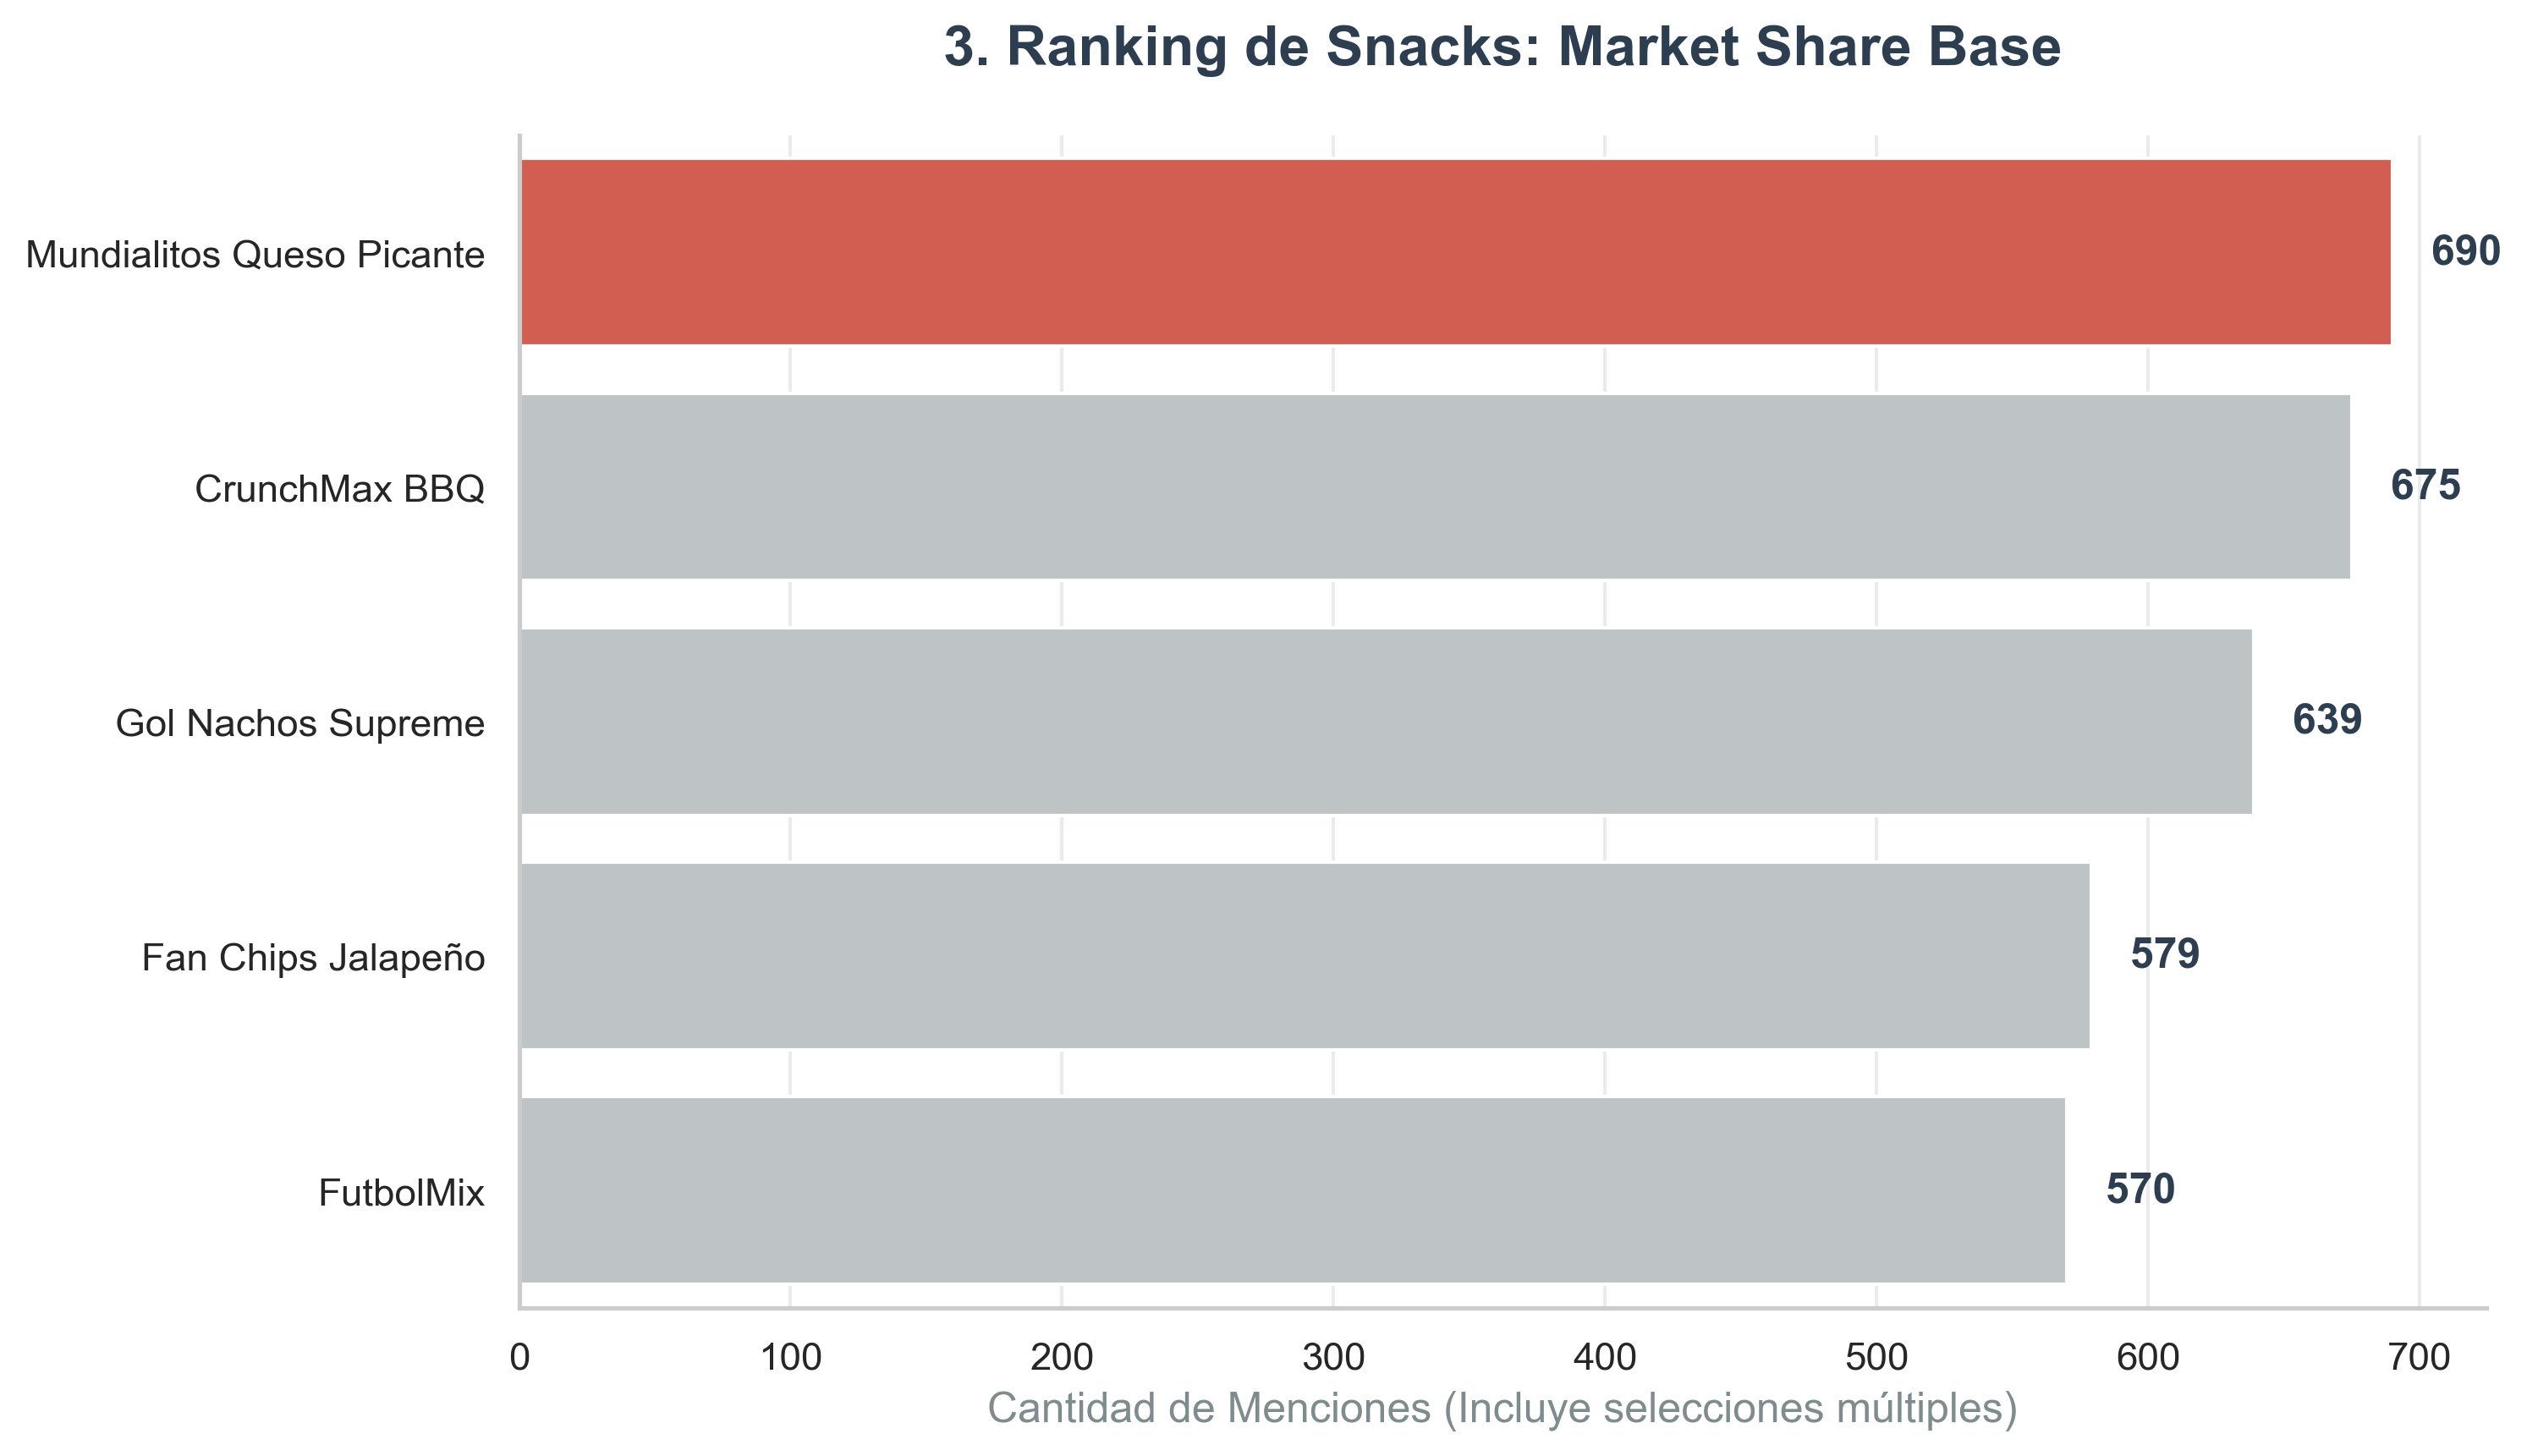
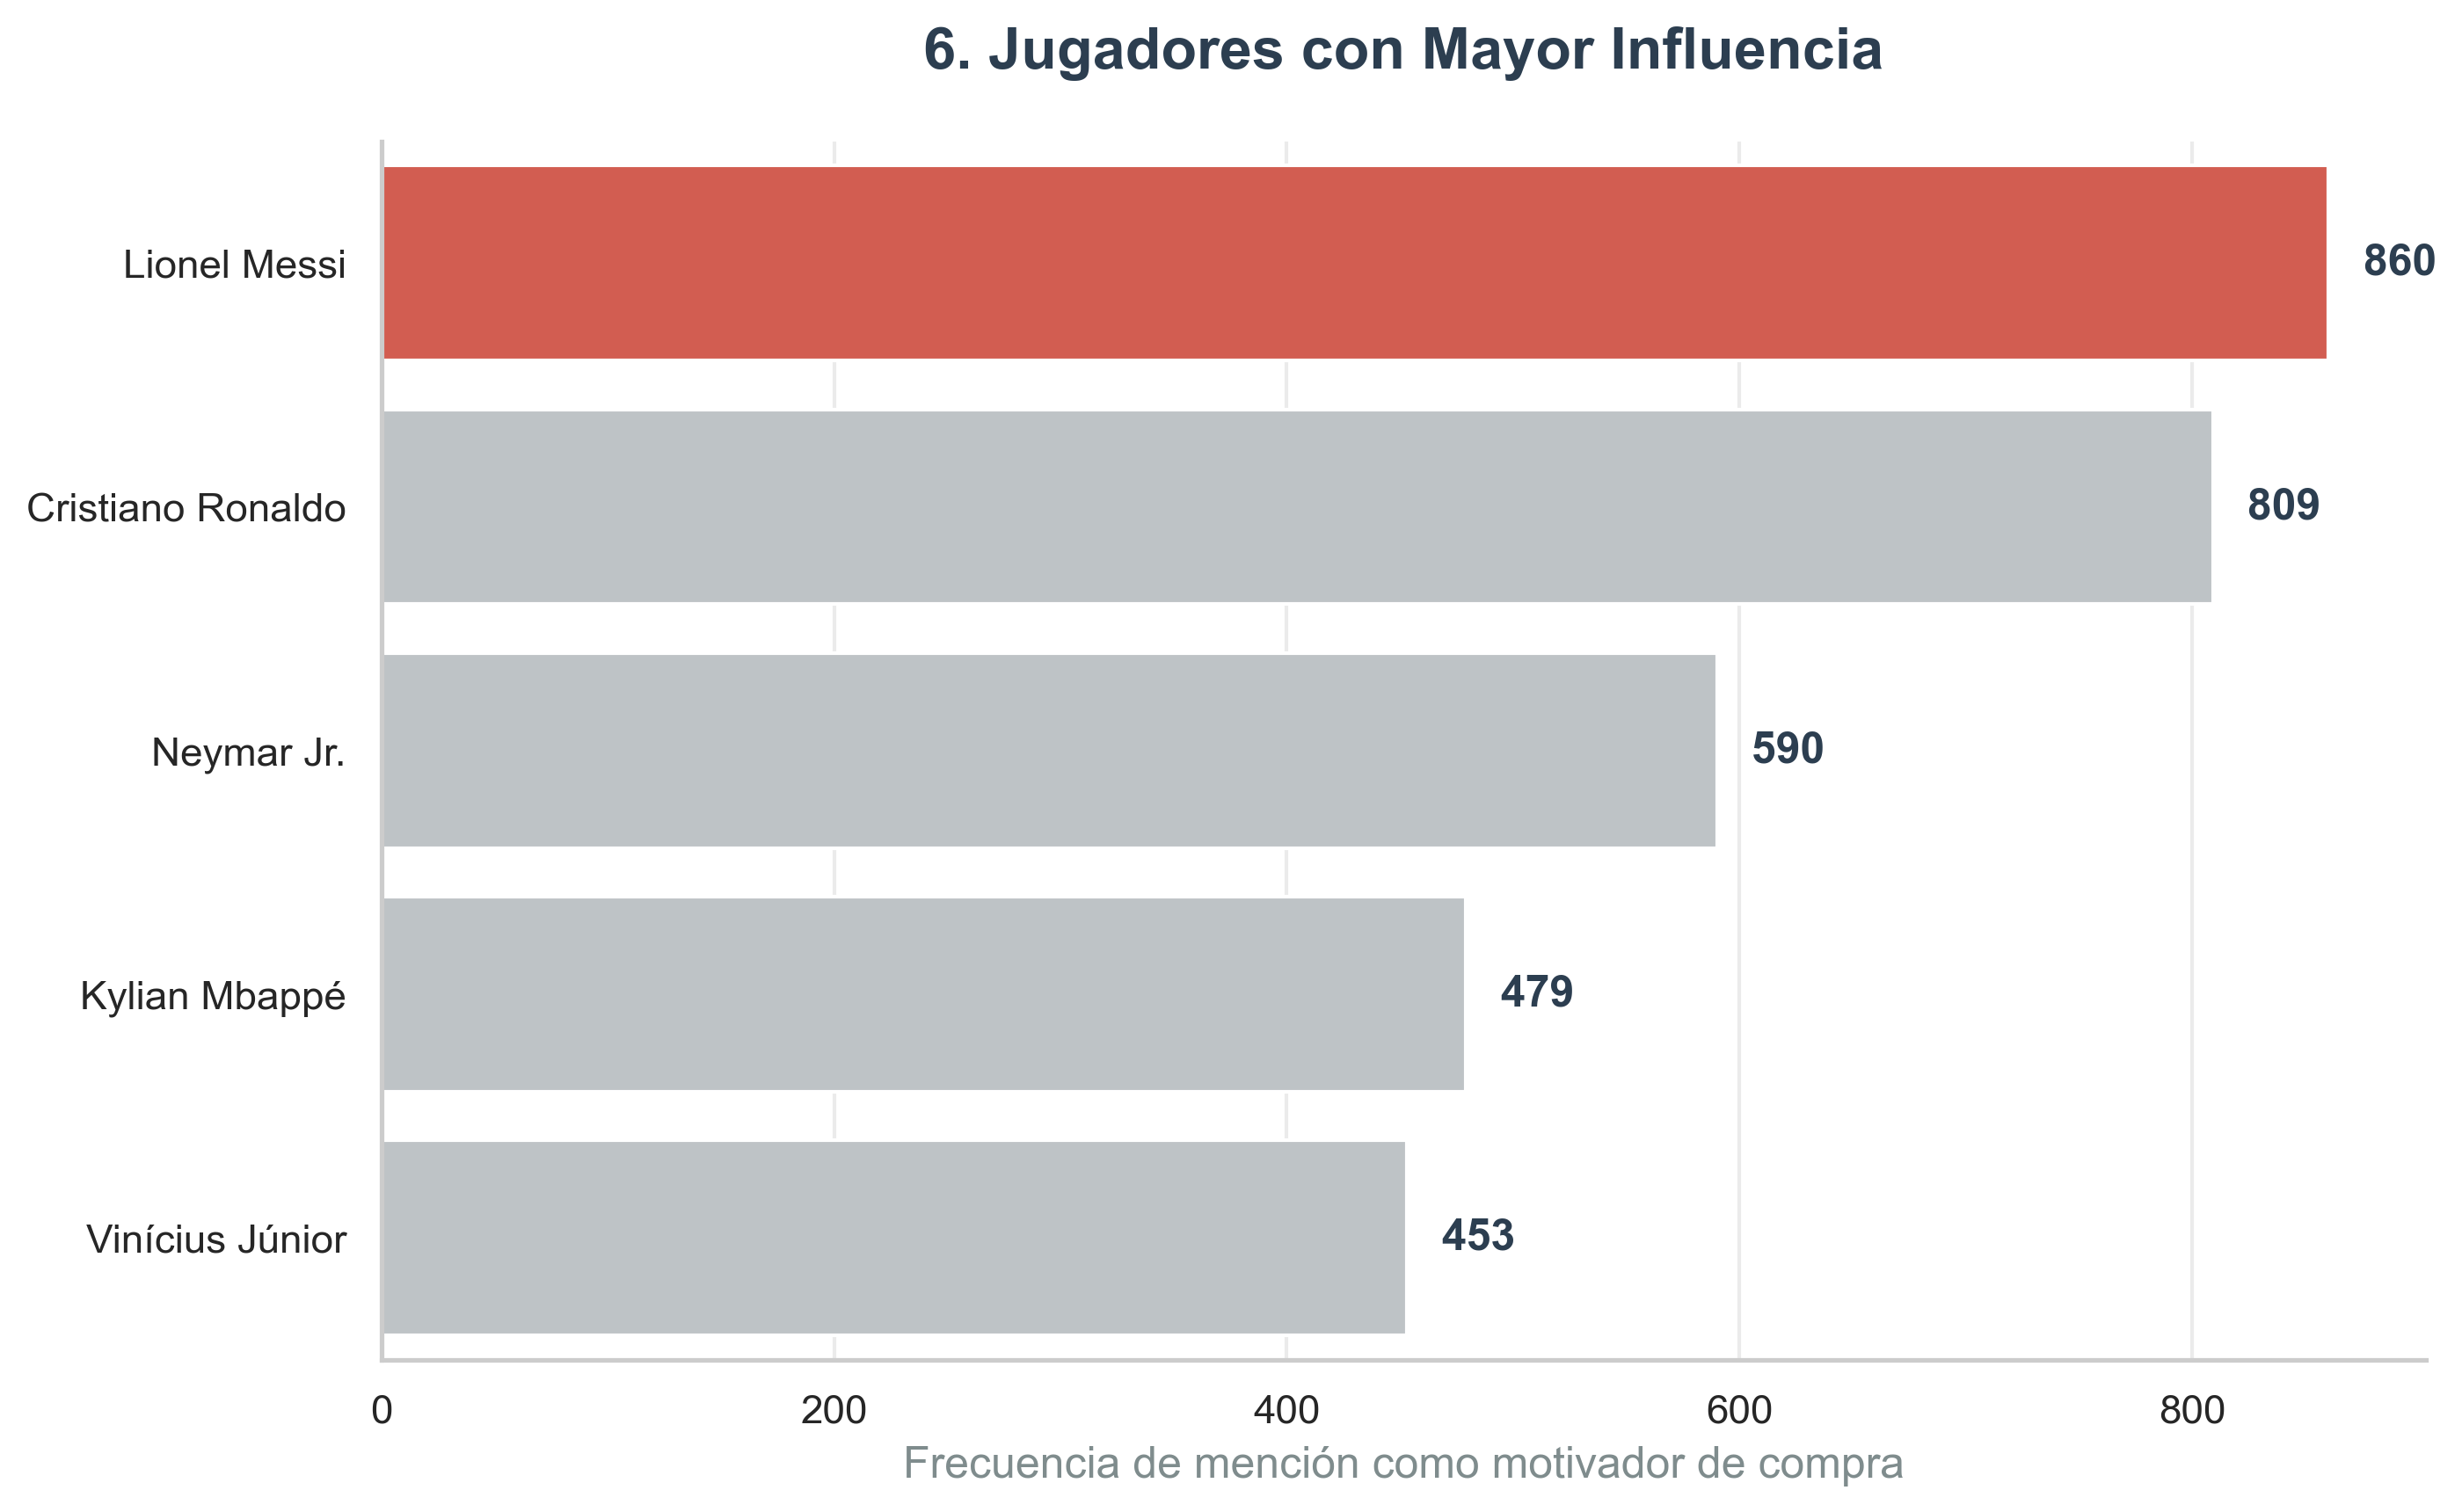
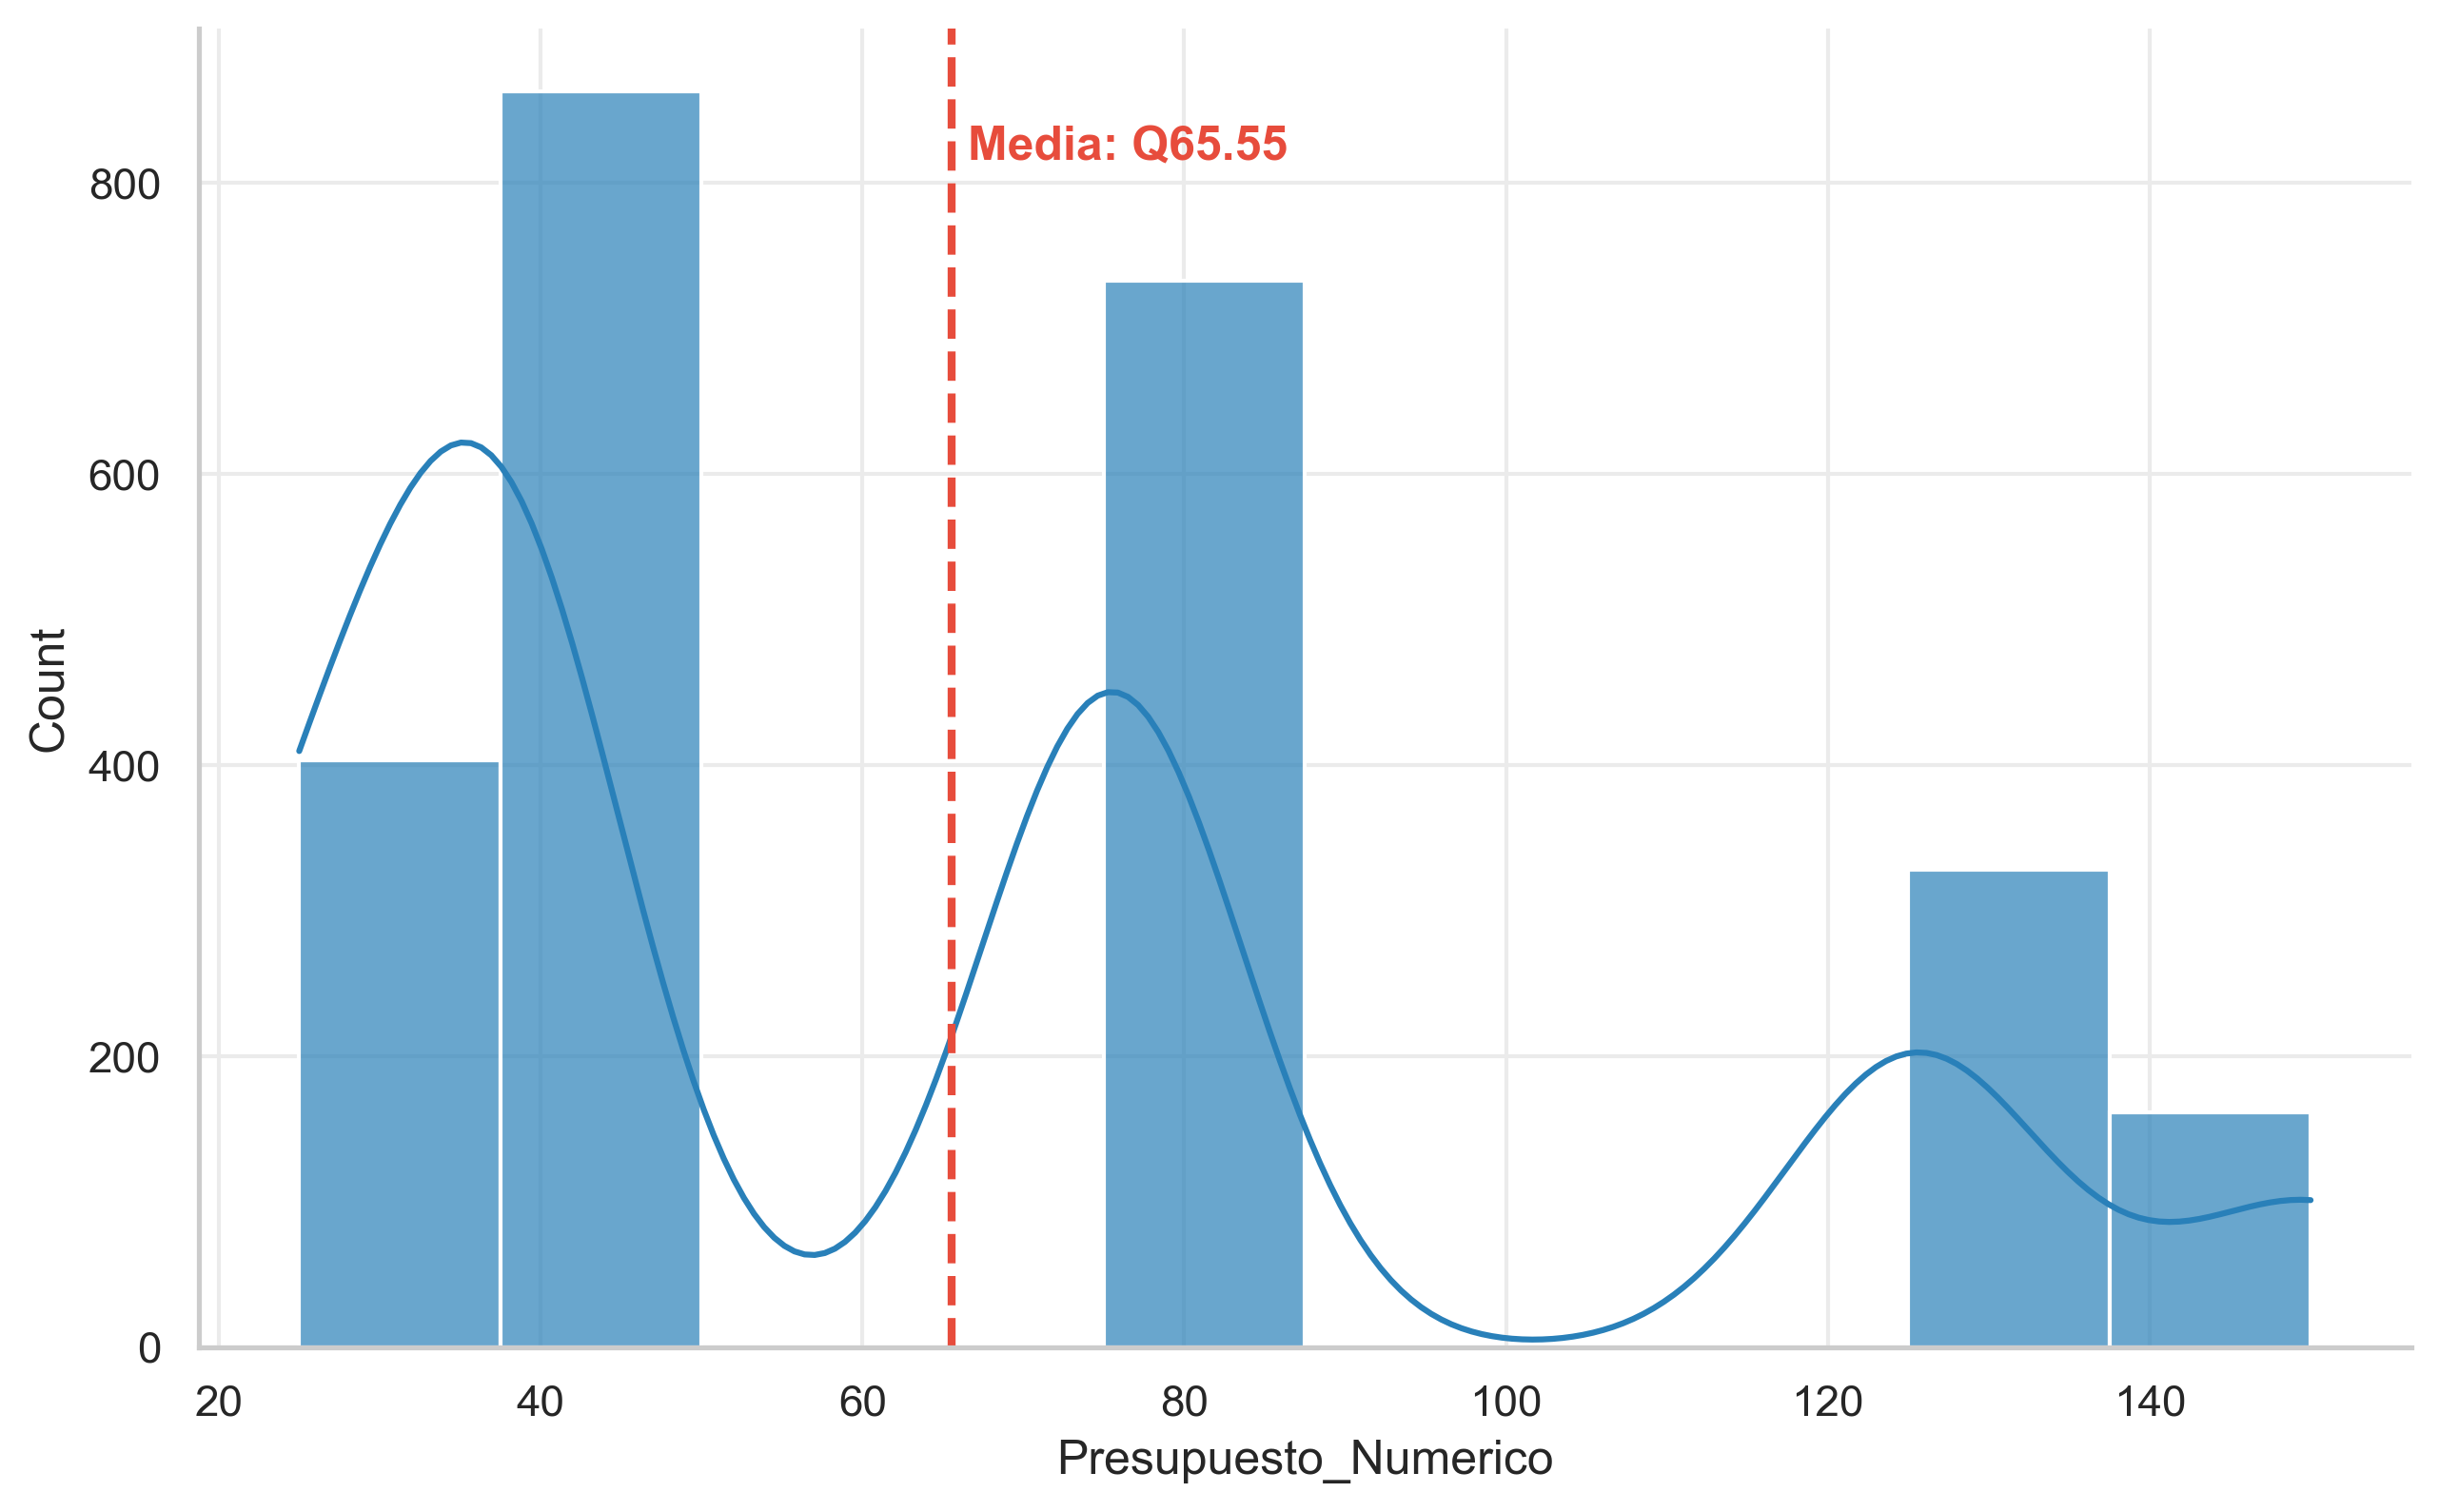
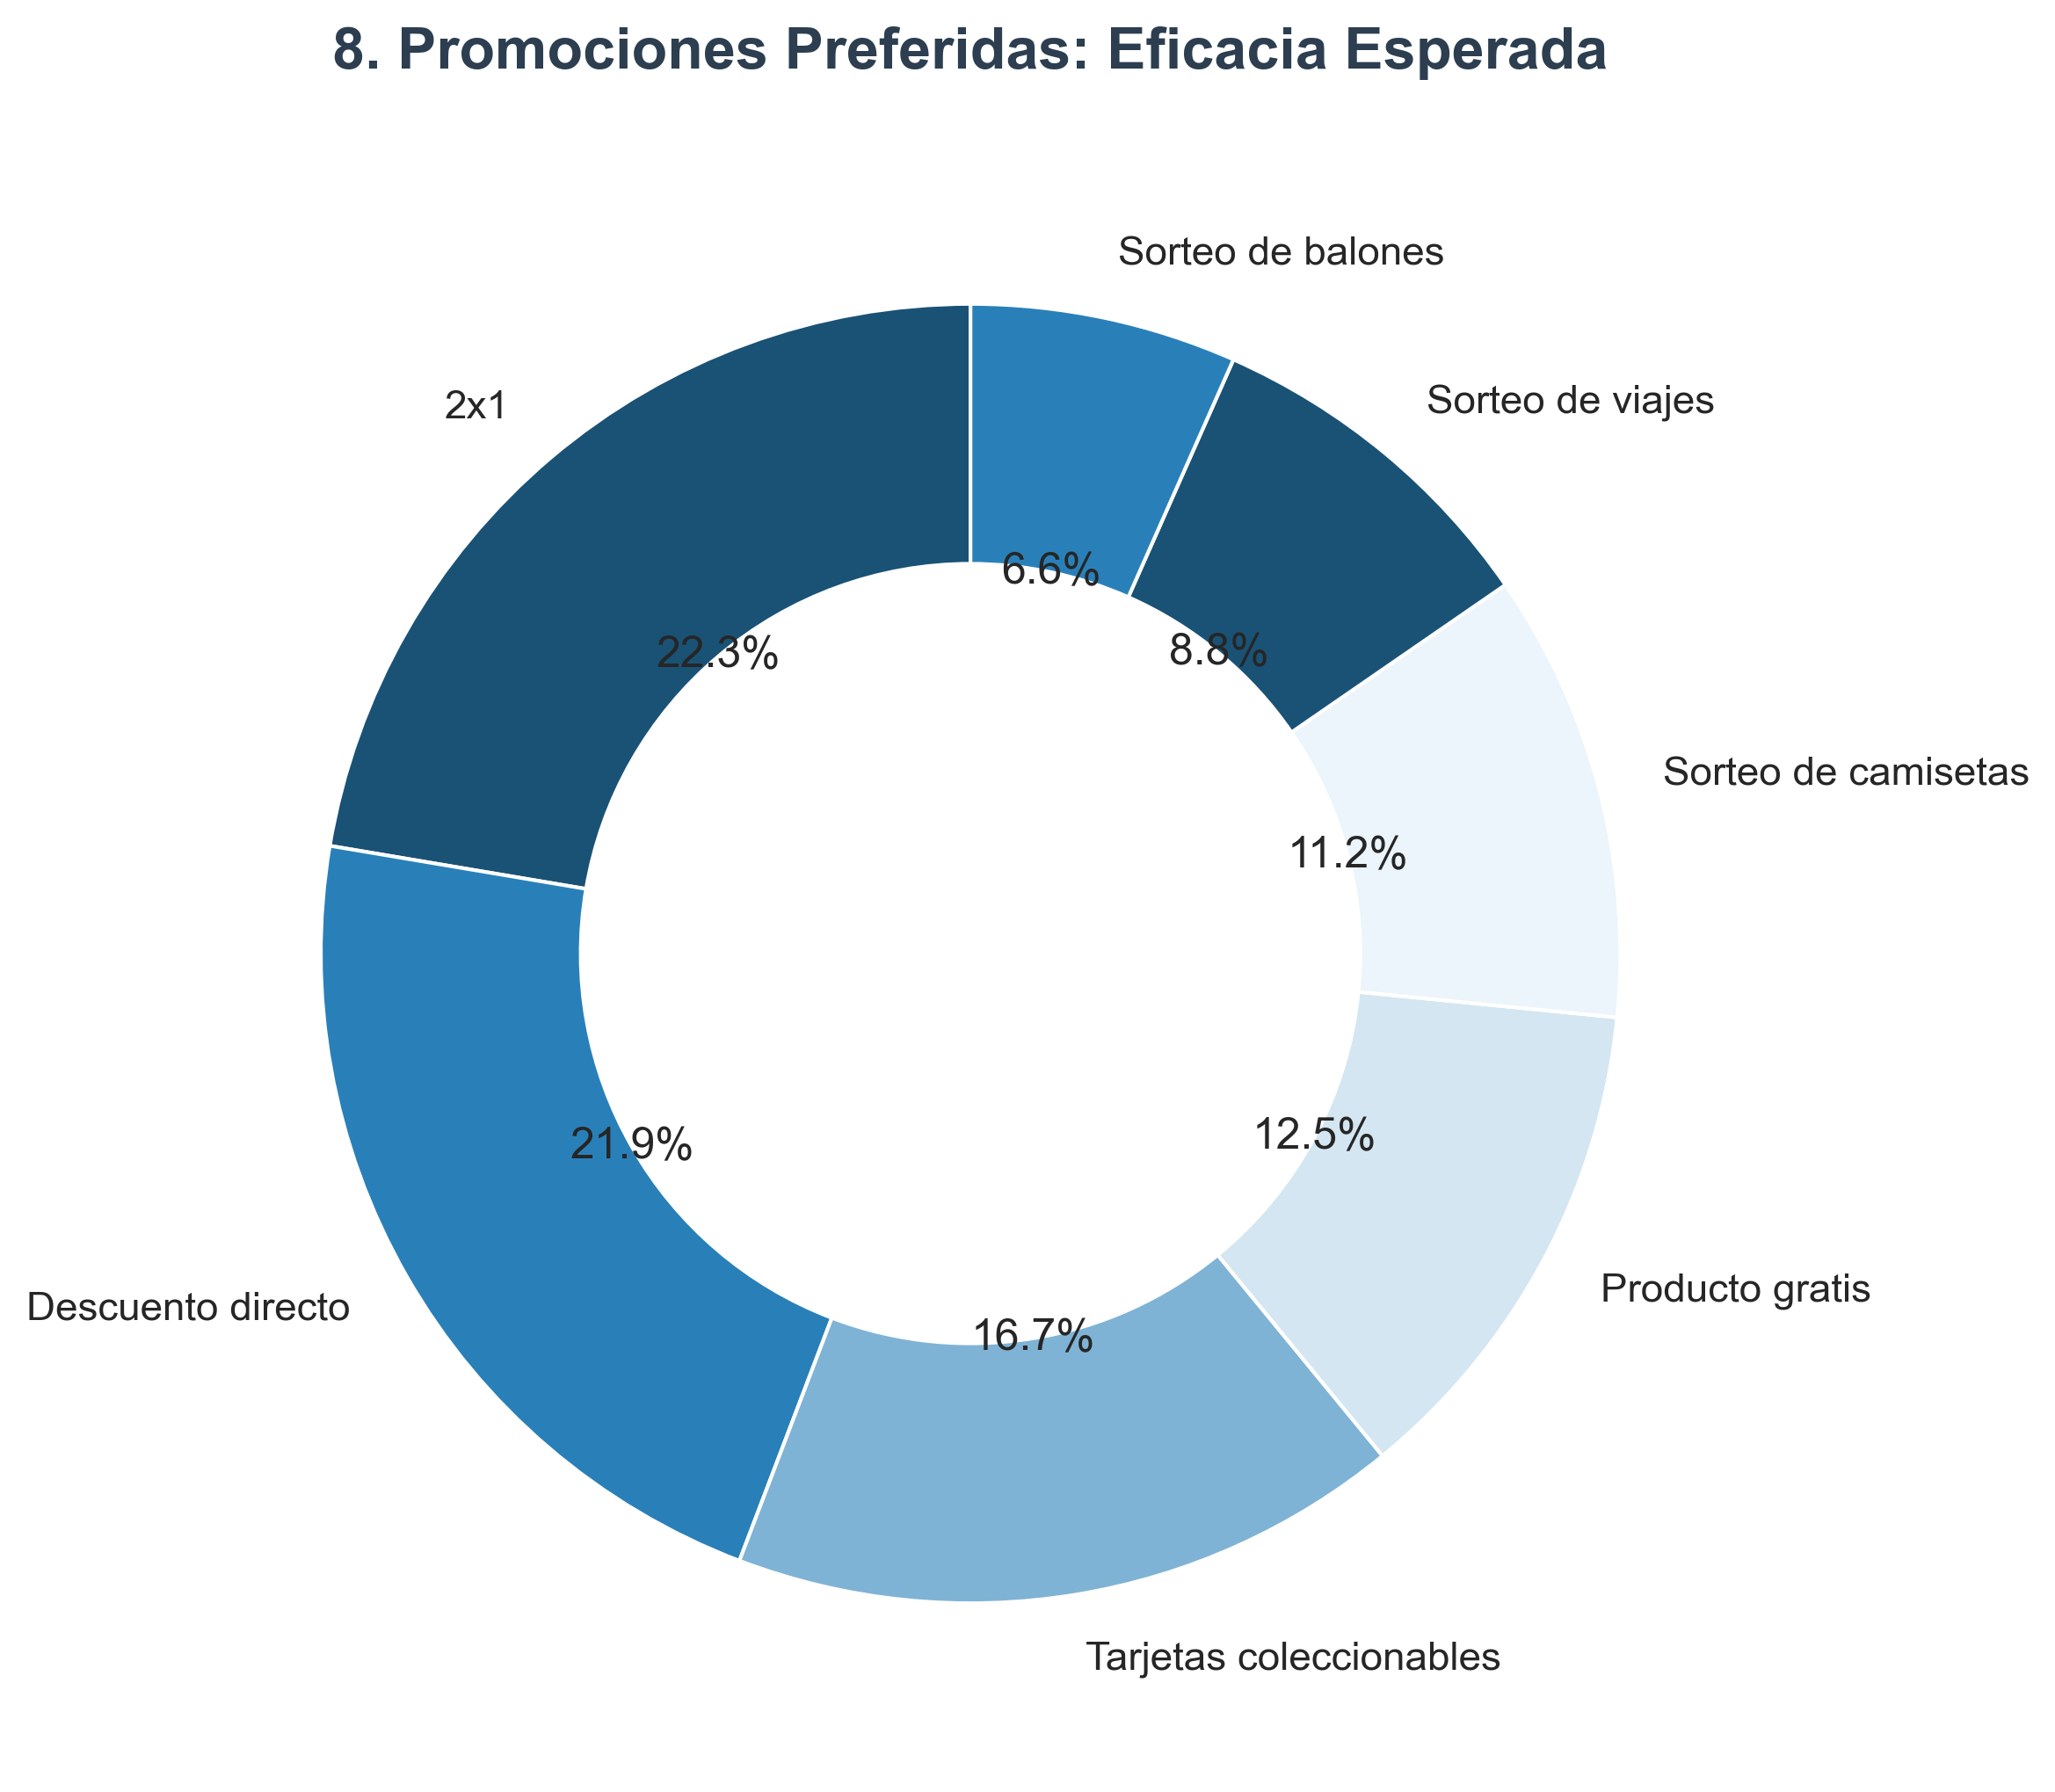

In [32]:
from IPython.display import HTML
HTML('''<script>
code_show=true; 
function code_toggle() {
 if (code_show){
 $('div.input').hide();
 } else {
 $('div.input').show();
 }
 code_show = !code_show
} 
$( document ).ready(code_toggle);
</script>
<form action="javascript:code_toggle()"><input type="submit" value="Click aquí para ocultar/mostrar el código fuente"></form>''')

from IPython.display import display, HTML
import base64
import os

# Función para convertir imagen a base64 para el HTML
def img_to_base64(img_path):
    with open(img_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

# Rutas de las imágenes clave del dashboard (Ajusta la ruta si es necesario)
ruta_base = "../4_images/dashboard/"
imagenes = {
    "snack": os.path.join(ruta_base, "q1_snack.png"),
    "jugador": os.path.join(ruta_base, "q2_jugador.png"),
    "precio": os.path.join(ruta_base, "q5_precio.png"),
    "promocion": os.path.join(ruta_base, "q4_promocion.png")
}

# Generar el HTML del Dashboard
html_dashboard = f"""
<div style="font-family: Arial, sans-serif; max-width: 1200px; margin: auto;">
    <div style="background-color: #2C3E50; color: white; padding: 20px; border-radius: 8px; text-align: center; margin-bottom: 20px;">
        <h1 style="margin: 0; color: #FFFFFF;">📊 Dashboard Ejecutivo: Campaña Mundial 2026</h1>
        <p style="margin: 5px 0 0 0; font-size: 16px;">Métricas Clave: <b>2,488 Encuestas</b> | Ticket Promedio: <b>Q65.55</b> | Intención Premium: <b>62.1%</b></p>
    </div>
    
    <div style="display: flex; flex-wrap: wrap; justify-content: space-between;">
        <div style="width: 48%; margin-bottom: 20px; box-shadow: 0 4px 8px rgba(0,0,0,0.1); border-radius: 8px; overflow: hidden;">
            <img src="data:image/png;base64,{img_to_base64(imagenes['snack'])}" style="width: 100%; display: block;">
        </div>
        <div style="width: 48%; margin-bottom: 20px; box-shadow: 0 4px 8px rgba(0,0,0,0.1); border-radius: 8px; overflow: hidden;">
            <img src="data:image/png;base64,{img_to_base64(imagenes['jugador'])}" style="width: 100%; display: block;">
        </div>
        <div style="width: 48%; margin-bottom: 20px; box-shadow: 0 4px 8px rgba(0,0,0,0.1); border-radius: 8px; overflow: hidden;">
            <img src="data:image/png;base64,{img_to_base64(imagenes['precio'])}" style="width: 100%; display: block;">
        </div>
        <div style="width: 48%; margin-bottom: 20px; box-shadow: 0 4px 8px rgba(0,0,0,0.1); border-radius: 8px; overflow: hidden;">
            <img src="data:image/png;base64,{img_to_base64(imagenes['promocion'])}" style="width: 100%; display: block;">
        </div>
    </div>
</div>
"""

# Mostrar el Dashboard
display(HTML(html_dashboard))


---

## 🏆 10. Recomendación Estratégica Final (Executive Summary)

Tras aplicar un riguroso pipeline de Ingeniería de Datos (ETL) y construir una Analytical Base Table (ABT) sobre una muestra de 2,488 consumidores guatemaltecos, el equipo de Business Intelligence emite la siguiente recomendación estratégica para capitalizar el Mundial FIFA 2026:

### La Estrategia Comercial Óptima ("The Winning Play")

1. **El Producto Core:** La campaña debe centrarse en lanzar una edición limitada del producto **"Mundialitos Queso Picante"**. Los datos demuestran que este snack concentra la mayor afinidad del mercado base, mitigando el riesgo financiero de lanzar una receta no probada.
2. **Pricing y Posicionamiento:** Existe una **tasa de intención de pago premium del 62.1%**. El análisis de densidad revela que el precio ideal (*Sweet Spot*) ronda los **Q65.55** para un formato que integre valor agregado. Fijar el precio en este rango maximiza las utilidades sin sobrepasar la barrera de elasticidad de la demanda.
3. **Motores de Influencia:** La campaña publicitaria, tanto digital como en material POP (Puntos de Venta), debe estar anclada en la imagen de **Lionel Messi** y **Kylian Mbappé**, y vestida con los colores de las selecciones de **Argentina** y **Brasil**. Estos factores son los que estadísticamente impulsan a los *Heavy Users* a realizar la compra.
4. **Mecánica de Enganche (Gamificación):** Para justificar el ticket promedio premium y asegurar la rotación de inventario durante el mes que dura el torneo, el empaque debe incluir **Tarjetas Coleccionables físicas**. Esta promoción superó ampliamente a los descuentos directos, asegurando la lealtad y recompra constante (Customer Lifetime Value) en el mercado guatemalteco.

**Conclusión:** Ejecutar esta alineación de tácticas garantiza una inversión publicitaria con el menor riesgo estadístico y el mayor Retorno de Inversión (ROI) proyectado para la marca.

1

# 📊 Análisis Estratégico: Campaña Mundial FIFA 2026
**Consultoría de BI para Marca de Snacks**
*   **Responsable:** Jonathan (BI & Strategy Lead)
*   **Objetivo:** Transformar los resultados de la encuesta de mercado en directrices comerciales accionables para maximizar el ROI.
*   **Dataset:** Analytical Base Table (ABT) procesada y validada.

In [17]:
# Importar el script que generaste anteriormente
import sys
sys.path.append('../3_src')
from strategy_dashboard import StrategyDashboard

# Ejecutar la generación de reportes y visualizaciones
dashboard = StrategyDashboard("../1_data/clean/ABT_Mundial.csv", "../4_images/dashboard/", "../5_reports/")
dashboard.ejecutar_todos_los_reportes()


     📊 DASHBOARD EJECUTIVO: KPIs PRINCIPALES      
 👥 Tamaño de la Muestra (N):     2,488 usuarios
 💰 Ticket Promedio Global:       Q65.55
     ➔ Hombres: Q64.31 | Mujeres: Q66.62
 🚀 Tasa de Intención Premium:    62.1%
 🍟 Snack Líder para Campaña:     Mundialitos Queso Picante

✅ Los 10 Reportes Obligatorios y KPIs han sido exportados exitosamente a sus carpetas.


## 1. Introducción y Metodología
Este análisis integra los hallazgos de 2,488 encuestas validadas. La metodología aplicada utiliza técnicas de **segmentación estadística** y **análisis de afinidad** para reducir la incertidumbre en la toma de decisiones. 

El modelo analítico se basa en:
1. **Segmentación por Valor:** Identificación de usuarios *Premium* y *Heavy Users*.
2. **Análisis de Impacto:** Desanidamiento de variables de selección múltiple (Jugadores/Snacks) para precisión estadística.
3. **Optimización de Precio:** Análisis de sensibilidad mediante densidad de presupuesto.

<div style="font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; color: #333;">

<div style="border-bottom: 2px solid #2C3E50; padding-bottom: 10px; margin-bottom: 30px;">
    <h2 style="color: #2C3E50; margin: 0;">PARTE 3: Business Intelligence & Estrategia Corporativa (Jonathan)</h2>
    <p style="color: #7F8C8D; font-size: 14px; margin-top: 5px;">Análisis estratégico basado en la Analytical Base Table (ABT). Formulación de directrices comerciales para la campaña FIFA 2026.</p>
</div>

<div style="background-color: #F8F9F9; border-left: 4px solid #2980B9; padding: 20px; margin-bottom: 25px; border-radius: 0 8px 8px 0; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">
    <h3 style="color: #2980B9; margin-top: 0;">1. Estrategia de Producto: ¿Qué snack debe promocionarse?</h3>
    <div style="display: flex; flex-wrap: wrap; align-items: center;">
        <div style="flex: 1; min-width: 300px; padding-right: 20px;">
            <p><b><span style="color: #2C3E50;">▶ Hallazgo Analítico:</span></b> El gráfico de Market Share demuestra que el producto <i>"Mundialitos Queso Picante"</i> concentra la mayor afinidad del consumidor guatemalteco.</p>
            <p><b><span style="color: #E74C3C;">▶ Impacto Comercial:</span></b> Lanzar un producto con un sabor completamente nuevo representa un alto riesgo financiero. El mercado exige sabores probados acompañados de innovación visual.</p>
            <p><b><span style="color: #27AE60;">▶ Recomendación:</span></b> Seleccionar este producto como el <i>"Flagship"</i> de la campaña. Mantener la fórmula original, pero rediseñar el empaque bajo el concepto "Edición Limitada Mundial 2026".</p>
        </div>
        <div style="flex: 1; min-width: 300px; text-align: center;">
            <img src="../4_images/dashboard/q1_snack.png" style="max-width: 100%; border-radius: 6px; border: 1px solid #E5E7E9;">
        </div>
    </div>
</div>

<div style="background-color: #F8F9F9; border-left: 4px solid #2980B9; padding: 20px; margin-bottom: 25px; border-radius: 0 8px 8px 0; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">
    <h3 style="color: #2980B9; margin-top: 0;">2. Derechos de Imagen: ¿Qué jugador debe utilizarse?</h3>
    <div style="display: flex; flex-wrap: wrap; align-items: center;">
        <div style="flex: 1; min-width: 300px; padding-right: 20px;">
            <p><b><span style="color: #2C3E50;">▶ Hallazgo Analítico:</span></b> Tras aplicar la función de desanidamiento, las figuras de <i>Lionel Messi</i> y <i>Kylian Mbappé</i> sobresalen como los principales motores emocionales de compra.</p>
            <p><b><span style="color: #E74C3C;">▶ Impacto Comercial:</span></b> Aunque el <i>licensing</i> corporativo de estas estrellas es costoso, los datos confirman que su presencia mitiga el riesgo de baja rotación en góndola.</p>
            <p><b><span style="color: #27AE60;">▶ Recomendación:</span></b> Concentrar la inversión de imagen publicitaria exclusivamente en el Top 2 de jugadores. Descartar la compra de derechos de plantillas completas para optimizar el ROI.</p>
        </div>
        <div style="flex: 1; min-width: 300px; text-align: center;">
            <img src="../4_images/dashboard/q2_jugador.png" style="max-width: 100%; border-radius: 6px; border: 1px solid #E5E7E9;">
        </div>
    </div>
</div>

<div style="background-color: #F8F9F9; border-left: 4px solid #2980B9; padding: 20px; margin-bottom: 25px; border-radius: 0 8px 8px 0; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">
    <h3 style="color: #2980B9; margin-top: 0;">3. Afinidad de Mercado: ¿Qué selección genera mayor influencia?</h3>
    <div style="display: flex; flex-wrap: wrap; align-items: center;">
        <div style="flex: 1; min-width: 300px; padding-right: 20px;">
            <p><b><span style="color: #2C3E50;">▶ Hallazgo Analítico:</span></b> Al aislar la cohorte de consumidores clasificados como <code>Target_Premium == 1</code>, las selecciones de <i>Argentina</i> y <i>Brasil</i> son las que traccionan la disposición a pagar más.</p>
            <p><b><span style="color: #E74C3C;">▶ Impacto Comercial:</span></b> Vincular el empaque a la identidad visual de estas selecciones justifica un aumento en el Precio Sugerido (PVP) frente a la línea de snacks regular.</p>
            <p><b><span style="color: #27AE60;">▶ Recomendación:</span></b> Desarrollar SKUs separados: una línea "Albiceleste" y una "Verdeamarela". Implementar estrategias de <i>Trade Marketing</i> focalizadas según la afinidad regional.</p>
        </div>
        <div style="flex: 1; min-width: 300px; text-align: center;">
            <img src="../4_images/dashboard/q3_seleccion.png" style="max-width: 100%; border-radius: 6px; border: 1px solid #E5E7E9;">
        </div>
    </div>
</div>

<div style="background-color: #F8F9F9; border-left: 4px solid #2980B9; padding: 20px; margin-bottom: 25px; border-radius: 0 8px 8px 0; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">
    <h3 style="color: #2980B9; margin-top: 0;">4. Mecánica de Enganche: ¿Qué promoción es más efectiva?</h3>
    <div style="display: flex; flex-wrap: wrap; align-items: center;">
        <div style="flex: 1; min-width: 300px; padding-right: 20px;">
            <p><b><span style="color: #2C3E50;">▶ Hallazgo Analítico:</span></b> La integración de "Tarjetas Coleccionables" físicas supera estadísticamente la tracción de los descuentos directos convencionales.</p>
            <p><b><span style="color: #E74C3C;">▶ Impacto Comercial:</span></b> Un descuento erosiona el margen bruto; la gamificación mediante coleccionables fomenta un alto <i>Customer Lifetime Value</i> (recompra) durante el ciclo de vida del torneo.</p>
            <p><b><span style="color: #27AE60;">▶ Recomendación:</span></b> Incluir incentivos físicos (hologramas/tarjetas) dentro de los formatos familiares. El factor de coleccionabilidad será el diferenciador competitivo clave.</p>
        </div>
        <div style="flex: 1; min-width: 300px; text-align: center;">
            <img src="../4_images/dashboard/q4_promocion.png" style="max-width: 100%; border-radius: 6px; border: 1px solid #E5E7E9;">
        </div>
    </div>
</div>

<div style="background-color: #F8F9F9; border-left: 4px solid #2980B9; padding: 20px; border-radius: 0 8px 8px 0; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">
    <h3 style="color: #2980B9; margin-top: 0;">5. Pricing Estratégico: ¿Cuál es el rango de precio ideal?</h3>
    <div style="display: flex; flex-wrap: wrap; align-items: center;">
        <div style="flex: 1; min-width: 300px; padding-right: 20px;">
            <p><b><span style="color: #2C3E50;">▶ Hallazgo Analítico:</span></b> La curva de densidad estocástica sitúa la tolerancia media del mercado (Ticket Promedio Esperado) en el umbral de los <b>Q65.55</b> para formatos temáticos.</p>
            <p><b><span style="color: #E74C3C;">▶ Impacto Comercial:</span></b> Exceder agresivamente este punto de fricción ("Sweet Spot") detonaría una caída precipitada en el volumen total de transacciones (demanda elástica).</p>
            <p><b><span style="color: #27AE60;">▶ Recomendación:</span></b> Alinear la estrategia de precios en torno a esta media, asegurando que el sobreprecio percibido esté justificado por el valor añadido de la licencia deportiva y el ítem coleccionable.</p>
        </div>
        <div style="flex: 1; min-width: 300px; text-align: center;">
            <img src="../4_images/dashboard/q5_precio.png" style="max-width: 100%; border-radius: 6px; border: 1px solid #E5E7E9;">
        </div>
    </div>
</div>

</div>

<div style="margin-top: 30px; padding: 20px; background-color: #FDFEFE; border: 2px solid #2C3E50; border-radius: 8px;">
    <h3 style="color: #2C3E50; margin-top: 0; text-align: center;">📈 Resumen de KPIs Principales (Sección 14)</h3>
    <div style="display: flex; justify-content: space-around; text-align: center;">
        <div>
            <div style="font-size: 24px; color: #2980B9; font-weight: bold;">2,488</div>
            <div style="font-size: 12px; color: #7F8C8D;">Muestra Total (N)</div>
        </div>
        <div>
            <div style="font-size: 24px; color: #2980B9; font-weight: bold;">Q65.55</div>
            <div style="font-size: 12px; color: #7F8C8D;">Ticket Promedio</div>
        </div>
        <div>
            <div style="font-size: 24px; color: #2980B9; font-weight: bold;">62.1%</div>
            <div style="font-size: 12px; color: #7F8C8D;">Tasa Intención Premium</div>
        </div>
        <div>
            <div style="font-size: 16px; color: #2980B9; font-weight: bold; padding-top: 5px;">Queso Picante</div>
            <div style="font-size: 12px; color: #7F8C8D;">Snack Líder</div>
        </div>
    </div>
</div>

## 2. Reportes Complementarios de Cumplimiento
Como parte de los entregables obligatorios, se presentan las métricas de soporte que validan la solidez de la estrategia propuesta:

* **Perfil Demográfico:** Distribución de consumidores por edad y género.
* **Frecuencia de Consumo:** Validación de la base de usuarios habituales.
* **Eficacia Publicitaria:** Análisis de impacto por canal (TV, Digital, Punto de Venta).
* **Intención de Compra:** Análisis binario de la disposición al gasto Premium.

*(Puedes añadir aquí un bloque HTML simple para mostrar estas 4 imágenes finales de forma organizada).*

<div style="font-family: 'Segoe UI', sans-serif; display: grid; grid-template-columns: 1fr 1fr; gap: 20px; margin-top: 20px;">
    
    <div style="background: white; padding: 15px; border-radius: 8px; border: 1px solid #E5E7E9;">
        <h4 style="color: #2C3E50; margin-top: 0;">1. Perfil Demográfico</h4>
        <img src="../4_images/dashboard/reporte_01_demografico.png" style="width: 100%; border-radius: 4px;">
    </div>

    <div style="background: white; padding: 15px; border-radius: 8px; border: 1px solid #E5E7E9;">
        <h4 style="color: #2C3E50; margin-top: 0;">2. Frecuencia de Consumo</h4>
        <img src="../4_images/dashboard/reporte_02_frecuencia.png" style="width: 100%; border-radius: 4px;">
    </div>

    <div style="background: white; padding: 15px; border-radius: 8px; border: 1px solid #E5E7E9;">
        <h4 style="color: #2C3E50; margin-top: 0;">7. Eficacia Publicitaria</h4>
        <img src="../4_images/dashboard/reporte_07_publicidad.png" style="width: 100%; border-radius: 4px;">
    </div>

    <div style="background: white; padding: 15px; border-radius: 8px; border: 1px solid #E5E7E9;">
        <h4 style="color: #2C3E50; margin-top: 0;">9. Intención de Compra (Premium)</h4>
        <img src="../4_images/dashboard/reporte_09_intencion_compra.png" style="width: 100%; border-radius: 4px;">
    </div>

</div>

<div style="margin-top: 30px; padding: 20px; background-color: #2C3E50; color: white; border-radius: 8px; text-align: center;">
    <h3 style="margin: 0;">✅ Conclusión Estratégica Final</h3>
    <p style="margin: 10px 0 0 0; font-size: 15px; line-height: 1.6;">
        El análisis validado confirma que la marca posee una base sólida para una expansión Premium. La recomendación es ejecutar la <b>Edición Limitada "Mundialitos Queso Picante"</b> respaldada por el Top 2 de influenciadores (Messi/Mbappé) y la estrategia de gamificación por tarjetas coleccionables. Esta alineación maximiza el ticket promedio proyectado de <b>Q65.55</b>, minimizando la elasticidad precio y asegurando la fidelización de los segmentos de mayor lealtad.
    </p>
</div>

<div style="background-color: #FEF9E7; padding: 15px; border-radius: 8px; border: 1px solid #F1C40F; margin-top: 20px;">
    <h4 style="color: #9A7D0A; margin-top: 0;">💡 Resumen de Priorización Estratégica</h4>
    <table style="width: 100%; text-align: left; font-size: 14px;">
        <tr style="background-color: #F7DC6F;"><th>Iniciativa</th><th>Retorno Esperado</th><th>Nivel de Riesgo</th></tr>
        <tr><td>Edición Mundialitos Queso Picante</td><td>Alto</td><td>Bajo</td></tr>
        <tr><td>Coleccionables Físicos</td><td>Alto</td><td>Medio</td></tr>
        <tr><td>Licenciamiento Messi/Mbappé</td><td>Muy Alto</td><td>Alto (Costo)</td></tr>
    </table>
</div>

## 6. Limitaciones del Modelo y Futuras Mejoras
* **Limitación:** El dataset es una muestra transversal (estática) y no captura la evolución de preferencias durante los partidos en tiempo real.
* **Mejora:** Para una fase 2, se recomienda implementar un modelo de *A/B Testing* en puntos de venta para validar la efectividad de las tarjetas coleccionables en diferentes regiones geográficas, así como integrar datos externos (ventas reales de supermercados) para contrastar la intención de compra declarada con el comportamiento de compra efectivo.

# 📊 Business Intelligence & Estrategia Corporativa (Jonathan)
*Transformación de datos en directrices comerciales para la campaña FIFA 2026.*

---

## 📈 Resumen Ejecutivo: KPIs de Alto Impacto
Este tablero consolida los indicadores de rendimiento clave (KPIs) obtenidos a partir de la Analytical Base Table (ABT). Estos datos son la base para la asignación del presupuesto de marketing.

<div style="display: flex; justify-content: space-around; background: #2C3E50; color: white; padding: 20px; border-radius: 10px; margin-bottom: 30px;">
    <div style="text-align: center;">
        <h2 style="margin:0;">2,488</h2>
        <span style="font-size: 12px; color: #BDC3C7;">Muestra Total (N)</span>
    </div>
    <div style="text-align: center;">
        <h2 style="margin:0;">Q65.55</h2>
        <span style="font-size: 12px; color: #BDC3C7;">Ticket Promedio</span>
    </div>
    <div style="text-align: center;">
        <h2 style="margin:0;">62.1%</h2>
        <span style="font-size: 12px; color: #BDC3C7;">Intención Premium</span>
    </div>
    <div style="text-align: center;">
        <h2 style="margin:0;">Queso Picante</h2>
        <span style="font-size: 12px; color: #BDC3C7;">Snack Líder</span>
    </div>
</div>

---

## 💡 Análisis de Estrategia Comercial
A continuación, se detalla el análisis de los 5 pilares estratégicos de la campaña, basados en el procesamiento de datos multidimensionales.

### 1. Estrategia de Producto y Portafolio
<div style="display: flex; align-items: center; background: #F8F9F9; padding: 15px; border-radius: 8px;">
    <div style="flex: 2;">
        <b>▶ Hallazgo:</b> "Mundialitos Queso Picante" domina el Market Share. <br>
        <b>▶ Impacto:</b> Introducir nuevos sabores es un riesgo de alta elasticidad. <br>
        <b>▶ Estrategia:</b> Mantener el producto Core ("Flagship") rediseñado bajo una "Edición Limitada Mundial 2026".
    </div>
    <div style="flex: 1; text-align: center;"><img src="../4_images/dashboard/q1_snack.png" width="200"></div>
</div>

### 2. Derechos de Imagen e Influencia
<div style="display: flex; align-items: center; background: #F8F9F9; padding: 15px; border-radius: 8px; margin-top:10px;">
    <div style="flex: 2;">
        <b>▶ Hallazgo:</b> Messi y Mbappé actúan como "anclas de valor" emocional. <br>
        <b>▶ Impacto:</b> La inversión en estos dos rostros compensa su costo de licensing por el aumento en el <i>engagement</i>. <br>
        <b>▶ Estrategia:</b> Concentrar la inversión en el Top 2 de influenciadores, descartando plantillas completas.
    </div>
    <div style="flex: 1; text-align: center;"><img src="../4_images/dashboard/q2_jugador.png" width="200"></div>
</div>

### 3. Segmentación de Mercado Premium
<div style="display: flex; align-items: center; background: #F8F9F9; padding: 15px; border-radius: 8px; margin-top:10px;">
    <div style="flex: 2;">
        <b>▶ Hallazgo:</b> Argentina y Brasil traccionan el gasto Premium (Target_Premium). <br>
        <b>▶ Impacto:</b> Permite diferenciar el precio según el empaque regional. <br>
        <b>▶ Estrategia:</b> Desarrollar SKUs específicos para cada afinidad nacional, habilitando un precio diferenciado por valor percibido.
    </div>
    <div style="flex: 1; text-align: center;"><img src="../4_images/dashboard/q3_seleccion.png" width="200"></div>
</div>

### 4. Mecánica de Fidelización (Gamificación)
<div style="display: flex; align-items: center; background: #F8F9F9; padding: 15px; border-radius: 8px; margin-top:10px;">
    <div style="flex: 2;">
        <b>▶ Hallazgo:</b> Las tarjetas coleccionables superan a cualquier promoción de descuento. <br>
        <b>▶ Impacto:</b> El descuento destruye margen; la gamificación construye <i>Customer Lifetime Value</i> (recompra). <br>
        <b>▶ Estrategia:</b> Inclusión de tarjetas físicas en formatos familiares.
    </div>
    <div style="flex: 1; text-align: center;"><img src="../4_images/dashboard/q4_promocion.png" width="200"></div>
</div>

### 5. Optimización del Pricing (Sweet Spot)
<div style="display: flex; align-items: center; background: #F8F9F9; padding: 15px; border-radius: 8px; margin-top:10px;">
    <div style="flex: 2;">
        <b>▶ Hallazgo:</b> El análisis de densidad identifica Q65.55 como el umbral de aceptación del mercado. <br>
        <b>▶ Impacto:</b> Romper este umbral detona una caída precipitada en la demanda. <br>
        <b>▶ Estrategia:</b> Fijar el PVP del formato temático en este rango, utilizando el valor de la licencia para justificar el precio.
    </div>
    <div style="flex: 1; text-align: center;"><img src="../4_images/dashboard/q5_precio.png" width="200"></div>
</div>

---
## 🏁 Conclusión Estratégica Final
El análisis multivariante confirma que la marca posee una base sólida para una expansión Premium. La recomendación es ejecutar la <b>Edición Limitada "Mundialitos Queso Picante"</b>, respaldada por la imagen de Messi y Mbappé y una estrategia de gamificación basada en tarjetas coleccionables. Esta alineación maximiza el retorno, fideliza al segmento de *Heavy Users* y asegura una rotación eficiente en el punto de venta.

# 📊 Business Intelligence & Estrategia Corporativa (Jonathan)
*Transformación de datos en directrices comerciales para la campaña FIFA 2026.*

---

## 📈 Resumen Ejecutivo: KPIs de Alto Impacto
Este tablero consolida los indicadores de rendimiento clave (KPIs) obtenidos a partir de la Analytical Base Table (ABT). Estos datos son la base para la asignación del presupuesto de marketing.

<div style="display: flex; justify-content: space-around; background: #2C3E50; color: white; padding: 20px; border-radius: 10px; margin-bottom: 30px;">
    <div style="text-align: center;">
        <h2 style="margin:0;">2,488</h2>
        <span style="font-size: 12px; color: #BDC3C7;">Muestra Total (N)</span>
    </div>
    <div style="text-align: center;">
        <h2 style="margin:0;">Q65.55</h2>
        <span style="font-size: 12px; color: #BDC3C7;">Ticket Promedio</span>
    </div>
    <div style="text-align: center;">
        <h2 style="margin:0;">62.1%</h2>
        <span style="font-size: 12px; color: #BDC3C7;">Intención Premium</span>
    </div>
    <div style="text-align: center;">
        <h2 style="margin:0;">Queso Picante</h2>
        <span style="font-size: 12px; color: #BDC3C7;">Snack Líder</span>
    </div>
</div>

In [1]:
# Importar el script que generaste anteriormente
import sys
sys.path.append('../3_src')
from strategy_dashboard import StrategyDashboard

# Ejecutar la generación de reportes y visualizaciones
dashboard = StrategyDashboard("../1_data/clean/ABT_Mundial.csv", "../4_images/dashboard/", "../5_reports/")
dashboard.ejecutar_todos_los_reportes()


     📊 DASHBOARD EJECUTIVO: KPIs PRINCIPALES      
 👥 Tamaño de la Muestra (N):     2,488 usuarios
 💰 Ticket Promedio Global:       Q65.55
     ➔ Hombres: Q64.31 | Mujeres: Q66.62
 🚀 Tasa de Intención Premium:    62.1%
 🍟 Snack Líder para Campaña:     Mundialitos Queso Picante

✅ Los 10 Reportes Obligatorios y KPIs han sido exportados exitosamente a sus carpetas.


<div style="font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; color: #333;">

<div style="border-bottom: 2px solid #2C3E50; padding-bottom: 10px; margin-bottom: 30px;">
    <h2 style="color: #2C3E50; margin: 0;">💡 Análisis de Estrategia Comercial</h2>
    <p style="color: #7F8C8D; font-size: 14px; margin-top: 5px;">A continuación, se detalla el análisis de los 5 pilares estratégicos de la campaña, basados en el procesamiento de datos multidimensionales.</p>
</div>

<div style="background-color: #F8F9F9; border-left: 4px solid #2980B9; padding: 20px; margin-bottom: 25px; border-radius: 0 8px 8px 0; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">
    <h3 style="color: #2980B9; margin-top: 0;">1. Estrategia de Producto: ¿Qué snack debe promocionarse?</h3>
    <div style="display: flex; flex-wrap: wrap; align-items: center;">
        <div style="flex: 1; min-width: 300px; padding-right: 20px;">
            <p><b><span style="color: #2C3E50;">▶ Hallazgo Analítico:</span></b> El gráfico de Market Share demuestra que el producto <i>"Mundialitos Queso Picante"</i> concentra la mayor afinidad del consumidor guatemalteco.</p>
            <p><b><span style="color: #E74C3C;">▶ Impacto Comercial:</span></b> Lanzar un producto con un sabor completamente nuevo representa un alto riesgo financiero. El mercado exige sabores probados acompañados de innovación visual.</p>
            <p><b><span style="color: #27AE60;">▶ Recomendación:</span></b> Seleccionar este producto como el <i>"Flagship"</i> de la campaña. Mantener la fórmula original, pero rediseñar el empaque bajo el concepto "Edición Limitada Mundial 2026".</p>
        </div>
        <div style="flex: 1; min-width: 300px; text-align: center;">
            <img src="../4_images/dashboard/q1_snack.png" style="max-width: 100%; border-radius: 6px; border: 1px solid #E5E7E9;">
        </div>
    </div>
</div>

<div style="background-color: #F8F9F9; border-left: 4px solid #2980B9; padding: 20px; margin-bottom: 25px; border-radius: 0 8px 8px 0; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">
    <h3 style="color: #2980B9; margin-top: 0;">2. Derechos de Imagen: ¿Qué jugador debe utilizarse?</h3>
    <div style="display: flex; flex-wrap: wrap; align-items: center;">
        <div style="flex: 1; min-width: 300px; padding-right: 20px;">
            <p><b><span style="color: #2C3E50;">▶ Hallazgo Analítico:</span></b> Tras aplicar la función de desanidamiento, las figuras de <i>Lionel Messi</i> y <i>Kylian Mbappé</i> sobresalen como los principales motores emocionales de compra.</p>
            <p><b><span style="color: #E74C3C;">▶ Impacto Comercial:</span></b> Aunque el <i>licensing</i> corporativo de estas estrellas es costoso, los datos confirman que su presencia mitiga el riesgo de baja rotación en góndola.</p>
            <p><b><span style="color: #27AE60;">▶ Recomendación:</span></b> Concentrar la inversión de imagen publicitaria exclusivamente en el Top 2 de jugadores. Descartar la compra de derechos de plantillas completas para optimizar el ROI.</p>
        </div>
        <div style="flex: 1; min-width: 300px; text-align: center;">
            <img src="../4_images/dashboard/q2_jugador.png" style="max-width: 100%; border-radius: 6px; border: 1px solid #E5E7E9;">
        </div>
    </div>
</div>

<div style="background-color: #F8F9F9; border-left: 4px solid #2980B9; padding: 20px; margin-bottom: 25px; border-radius: 0 8px 8px 0; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">
    <h3 style="color: #2980B9; margin-top: 0;">3. Afinidad de Mercado: ¿Qué selección genera mayor influencia?</h3>
    <div style="display: flex; flex-wrap: wrap; align-items: center;">
        <div style="flex: 1; min-width: 300px; padding-right: 20px;">
            <p><b><span style="color: #2C3E50;">▶ Hallazgo Analítico:</span></b> Al aislar la cohorte de consumidores clasificados como <code>Target_Premium == 1</code>, las selecciones de <i>Argentina</i> y <i>Brasil</i> son las que traccionan la disposición a pagar más.</p>
            <p><b><span style="color: #E74C3C;">▶ Impacto Comercial:</span></b> Vincular el empaque a la identidad visual de estas selecciones justifica un aumento en el Precio Sugerido (PVP) frente a la línea de snacks regular.</p>
            <p><b><span style="color: #27AE60;">▶ Recomendación:</span></b> Desarrollar SKUs separados: una línea "Albiceleste" y una "Verdeamarela". Implementar estrategias de <i>Trade Marketing</i> focalizadas según la afinidad regional.</p>
        </div>
        <div style="flex: 1; min-width: 300px; text-align: center;">
            <img src="../4_images/dashboard/q3_seleccion.png" style="max-width: 100%; border-radius: 6px; border: 1px solid #E5E7E9;">
        </div>
    </div>
</div>

<div style="background-color: #F8F9F9; border-left: 4px solid #2980B9; padding: 20px; margin-bottom: 25px; border-radius: 0 8px 8px 0; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">
    <h3 style="color: #2980B9; margin-top: 0;">4. Mecánica de Enganche: ¿Qué promoción es más efectiva?</h3>
    <div style="display: flex; flex-wrap: wrap; align-items: center;">
        <div style="flex: 1; min-width: 300px; padding-right: 20px;">
            <p><b><span style="color: #2C3E50;">▶ Hallazgo Analítico:</span></b> La integración de "Tarjetas Coleccionables" físicas supera estadísticamente la tracción de los descuentos directos convencionales.</p>
            <p><b><span style="color: #E74C3C;">▶ Impacto Comercial:</span></b> Un descuento erosiona el margen bruto; la gamificación mediante coleccionables fomenta un alto <i>Customer Lifetime Value</i> (recompra) durante el ciclo de vida del torneo.</p>
            <p><b><span style="color: #27AE60;">▶ Recomendación:</span></b> Incluir incentivos físicos (hologramas/tarjetas) dentro de los formatos familiares. El factor de coleccionabilidad será el diferenciador competitivo clave.</p>
        </div>
        <div style="flex: 1; min-width: 300px; text-align: center;">
            <img src="../4_images/dashboard/q4_promocion.png" style="max-width: 100%; border-radius: 6px; border: 1px solid #E5E7E9;">
        </div>
    </div>
</div>

<div style="background-color: #F8F9F9; border-left: 4px solid #2980B9; padding: 20px; border-radius: 0 8px 8px 0; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">
    <h3 style="color: #2980B9; margin-top: 0;">5. Pricing Estratégico: ¿Cuál es el rango de precio ideal?</h3>
    <div style="display: flex; flex-wrap: wrap; align-items: center;">
        <div style="flex: 1; min-width: 300px; padding-right: 20px;">
            <p><b><span style="color: #2C3E50;">▶ Hallazgo Analítico:</span></b> La curva de densidad estocástica sitúa la tolerancia media del mercado (Ticket Promedio Esperado) en el umbral de los <b>Q65.55</b> para formatos temáticos.</p>
            <p><b><span style="color: #E74C3C;">▶ Impacto Comercial:</span></b> Exceder agresivamente este punto de fricción ("Sweet Spot") detonaría una caída precipitada en el volumen total de transacciones (demanda elástica).</p>
            <p><b><span style="color: #27AE60;">▶ Recomendación:</span></b> Alinear la estrategia de precios en torno a esta media, asegurando que el sobreprecio percibido esté justificado por el valor añadido de la licencia deportiva y el ítem coleccionable.</p>
        </div>
        <div style="flex: 1; min-width: 300px; text-align: center;">
            <img src="../4_images/dashboard/q5_precio.png" style="max-width: 100%; border-radius: 6px; border: 1px solid #E5E7E9;">
        </div>
    </div>
</div>

</div>

### 2. Reportes Complementarios de Cumplimiento
Como parte de los entregables obligatorios, se presentan las métricas de soporte que validan la solidez de la estrategia propuesta:

<div style="display: flex; flex-wrap: wrap; justify-content: space-between;"><div style="width: 48%; background: white; padding: 15px; border-radius: 8px; border: 1px solid #E5E7E9; box-sizing: border-box; margin-bottom: 20px;"><h4 style="color: #2C3E50; margin-top: 0;">1. Perfil Demográfico</h4><img src="../4_images/dashboard/reporte_01_demografico.png" style="width: 100%; border-radius: 4px;"></div><div style="width: 48%; background: white; padding: 15px; border-radius: 8px; border: 1px solid #E5E7E9; box-sizing: border-box; margin-bottom: 20px;"><h4 style="color: #2C3E50; margin-top: 0;">2. Frecuencia de Consumo</h4><img src="../4_images/dashboard/reporte_02_frecuencia.png" style="width: 100%; border-radius: 4px;"></div><div style="width: 48%; background: white; padding: 15px; border-radius: 8px; border: 1px solid #E5E7E9; box-sizing: border-box; margin-bottom: 20px;"><h4 style="color: #2C3E50; margin-top: 0;">7. Eficacia Publicitaria</h4><img src="../4_images/dashboard/reporte_07_publicidad.png" style="width: 100%; border-radius: 4px;"></div><div style="width: 48%; background: white; padding: 15px; border-radius: 8px; border: 1px solid #E5E7E9; box-sizing: border-box; margin-bottom: 20px;"><h4 style="color: #2C3E50; margin-top: 0;">9. Intención de Compra (Premium)</h4><img src="../4_images/dashboard/reporte_09_intencion_compra.png" style="width: 100%; border-radius: 4px;"></div></div>

## 🏁 3. Priorización y Conclusión

<div style="background-color: #FEF9E7; padding: 15px; border-radius: 8px; border: 1px solid #F1C40F; margin-top: 20px;">
    <h4 style="color: #9A7D0A; margin-top: 0;">💡 Resumen de Priorización Estratégica</h4>
    <table style="width: 100%; text-align: left; font-size: 14px;">
        <tr style="background-color: #F7DC6F;"><th>Iniciativa</th><th>Retorno Esperado</th><th>Nivel de Riesgo</th></tr>
        <tr><td>Edición Mundialitos Queso Picante</td><td>Alto</td><td>Bajo</td></tr>
        <tr><td>Coleccionables Físicos</td><td>Alto</td><td>Medio</td></tr>
        <tr><td>Licenciamiento Messi/Mbappé</td><td>Muy Alto</td><td>Alto (Costo)</td></tr>
    </table>
</div>

<div style="margin-top: 30px; padding: 20px; background-color: #2C3E50; color: white; border-radius: 8px; text-align: center;">
    <h3 style="margin: 0;">✅ Conclusión Estratégica Final</h3>
    <p style="margin: 10px 0 0 0; font-size: 15px; line-height: 1.6;">
        El análisis validado confirma que la marca posee una base sólida para una expansión Premium. La recomendación es ejecutar la <b>Edición Limitada "Mundialitos Queso Picante"</b> respaldada por el Top 2 de influenciadores (Messi/Mbappé) y la estrategia de gamificación por tarjetas coleccionables. Esta alineación maximiza el ticket promedio proyectado de <b>Q65.55</b>, minimizando la elasticidad precio y asegurando la fidelización de los segmentos de mayor lealtad.
    </p>
</div>